# Medical Abstract Classification with BERT and PyTorch

This project uses a pretrained BERT Transformer to classify medical abstracts
into broad medical categories.

The implementation follows a standardized PyTorch workflow covering dataset
analysis, preprocessing, tokenization, train/validation/test splitting,
Transformer-based classification, fine-tuning, checkpointing, and detailed
evaluation.

In [ ]:
# Install required libraries
!pip install -q transformers datasets

In [ ]:
import torch
import torch.nn as nn

from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Select device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


## 2. Dataset Loading and Initial Exploration

The Medical Abstracts dataset contains labeled medical abstracts for
multi-class classification. Each sample consists of a medical abstract
and its corresponding condition label.

The dataset provides predefined training and testing splits. The test
split will remain untouched during model development and will only be
used for final evaluation.

In [ ]:
from datasets import load_dataset

# Load dataset from Hugging Face
dataset = load_dataset("TimSchopf/medical_abstracts")

print(dataset)

README.md:   0%|          | 0.00/4.96k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 7.67MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.94MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/11550 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2888 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['condition_label', 'medical_abstract'],
        num_rows: 11550
    })
    test: Dataset({
        features: ['condition_label', 'medical_abstract'],
        num_rows: 2888
    })
})


In [ ]:
print("Train samples:", len(dataset["train"]))
print("Test samples:", len(dataset["test"]))

print("\nFeatures:")
print(dataset["train"].features)

Train samples: 11550
Test samples: 2888

Features:
{'condition_label': Value('int64'), 'medical_abstract': Value('string')}


In [ ]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (11550, 2)
Test shape: (2888, 2)


,condition_label,medical_abstract
0,5,Tissue changes around loose prostheses. A cani...
1,1,Neuropeptide Y and neuron-specific enolase lev...
2,2,"Sexually transmitted diseases of the colon, re..."
3,1,Lipolytic factors associated with murine and h...
4,3,Does carotid restenosis predict an increased r...


In [ ]:
print("Unique labels:")
print(sorted(train_df["condition_label"].unique()))

print("\nLabel distribution:")
print(train_df["condition_label"].value_counts().sort_index())

Unique labels:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Label distribution:
condition_label
1    2530
2    1195
3    1540
4    2441
5    3844
Name: count, dtype: int64


In [ ]:
sample = train_df.iloc[0]

print("Label:", sample["condition_label"])
print("\nMedical Abstract:")
print(sample["medical_abstract"])

Label: 3

Medical Abstract:
Orbital intramuscular schwannoma. In an 8-year-old girl with asymptomatic proptosis, computed tomographic scans showed a large medial orbital mass that contoured the globe anteriorly, bowed the optic nerve laterally, and extended posteriorly to the orbital apex. T1-weighted coronal magnetic resonance images showed the mass to be a diffusely enlarged medial rectus muscle. Histopathologic examination of a medial rectus muscle biopsy specimen disclosed a multinodular, intramuscular schwannoma, separating and infiltrating normal skeletal muscle fibers. The intramuscular location and multinodular configuration of this tumor, together with its occurrence in a child, distinguish it from previous orbital schwannomas. 


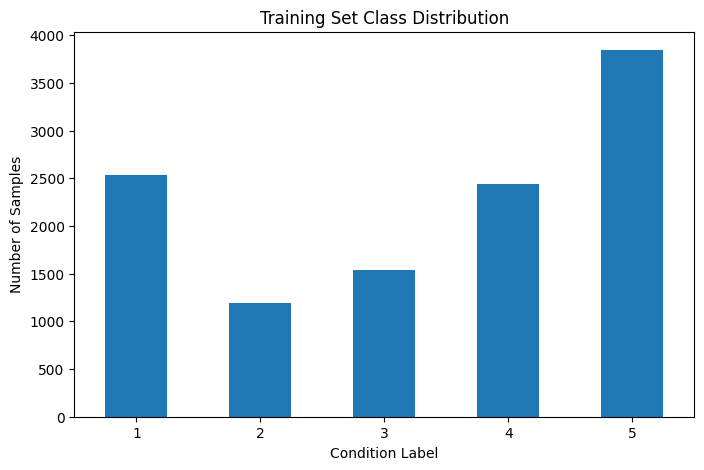

In [ ]:
# Check class balance

import matplotlib.pyplot as plt

label_counts = train_df["condition_label"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
label_counts.plot(kind="bar")

plt.xlabel("Condition Label")
plt.ylabel("Number of Samples")
plt.title("Training Set Class Distribution")
plt.xticks(rotation=0)
plt.show()

## 3. Train/Validation Split and Class Weighting

The original training split is divided into training and validation subsets
using stratified sampling so that the class distribution remains consistent.

The provided test split is kept completely untouched and will only be used
for final model evaluation.

Class weights are calculated exclusively from the training subset and will
be used with weighted CrossEntropyLoss to reduce the effect of class
imbalance.

In [ ]:
from datasets import load_dataset

# Load the label-name mapping provided by the dataset
label_dataset = load_dataset(
    "TimSchopf/medical_abstracts",
    "labels"
)

print(label_dataset)
print(label_dataset["train"].to_pandas())

labels/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.61kB            

labels/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['condition_label', 'condition_name'],
        num_rows: 5
    })
})
   condition_label                   condition_name
0                1                        neoplasms
1                2        digestive system diseases
2                3          nervous system diseases
3                4          cardiovascular diseases
4                5  general pathological conditions


In [ ]:
#Stratified Split
from sklearn.model_selection import train_test_split

# Original training data
train_data = train_df.copy()

# Create stratified train/validation split
train_df, val_df = train_test_split(
    train_data,
    test_size=0.15,
    stratify=train_data["condition_label"],
    random_state=42
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Train samples: 9817
Validation samples: 1733
Test samples: 2888


In [ ]:
print("Training distribution:")
print(
    train_df["condition_label"]
    .value_counts(normalize=True)
    .sort_index()
)

print("\nValidation distribution:")
print(
    val_df["condition_label"]
    .value_counts(normalize=True)
    .sort_index()
)

Training distribution:
condition_label
1    0.219008
2    0.103494
3    0.133340
4    0.211368
5    0.332790
Name: proportion, dtype: float64

Validation distribution:
condition_label
1    0.219273
2    0.103289
3    0.133295
4    0.211194
5    0.332949
Name: proportion, dtype: float64


In [ ]:
#Class weight
num_classes = 5

class_counts = (
    train_df["condition_label"]
    .value_counts()
    .sort_index()
)

total_samples = len(train_df)

class_weights = (
    total_samples /
    (num_classes * class_counts)
)

print("Class counts:")
print(class_counts)

print("\nClass weights:")
print(class_weights)

Class counts:
condition_label
1    2150
2    1016
3    1309
4    2075
5    3267
Name: count, dtype: int64

Class weights:
condition_label
1    0.913209
2    1.932480
3    1.499924
4    0.946217
5    0.600979
Name: count, dtype: float64


In [ ]:
#weight->Pytorch Tensor
class_weights_tensor = torch.tensor(
    class_weights.values,
    dtype=torch.float32
)

print("Class weights tensor:")
print(class_weights_tensor)

Class weights tensor:
tensor([0.9132, 1.9325, 1.4999, 0.9462, 0.6010])


## 4. Medical Abstract Length Analysis

BERT processes text as a sequence of tokens with a fixed maximum sequence
length. Abstracts longer than this limit must be truncated, while shorter
abstracts are padded when batching.

Before selecting the maximum sequence length, we analyze the token-length
distribution of the medical abstracts. This allows the sequence length to
be selected based on the characteristics of the dataset rather than using
an arbitrary value.

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer:", MODEL_NAME)
print("Vocabulary size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer: bert-base-uncased
Vocabulary size: 30522


In [ ]:
def get_token_lengths(texts):
    lengths = []

    for text in texts:
        token_ids = tokenizer.encode(
            text,
            add_special_tokens=True,
            truncation=False
        )
        lengths.append(len(token_ids))

    return np.array(lengths)


train_token_lengths = get_token_lengths(
    train_df["medical_abstract"].tolist()
)

print("Number of abstracts:", len(train_token_lengths))
print("Minimum tokens:", train_token_lengths.min())
print("Maximum tokens:", train_token_lengths.max())
print("Mean tokens:", train_token_lengths.mean())
print("Median tokens:", np.median(train_token_lengths))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (653 > 512). Running this sequence through the model will result in indexing errors


Number of abstracts: 9817
Minimum tokens: 38
Maximum tokens: 836
Mean tokens: 279.42823673219925
Median tokens: 269.0


In [ ]:
#Calculate useful percentiles
percentiles = [50, 75, 90, 95, 99]

print("Token length percentiles:")

for p in percentiles:
    value = np.percentile(train_token_lengths, p)
    print(f"{p}th percentile: {value:.0f} tokens")

Token length percentiles:
50th percentile: 269 tokens
75th percentile: 363 tokens
90th percentile: 440 tokens
95th percentile: 489 tokens
99th percentile: 611 tokens


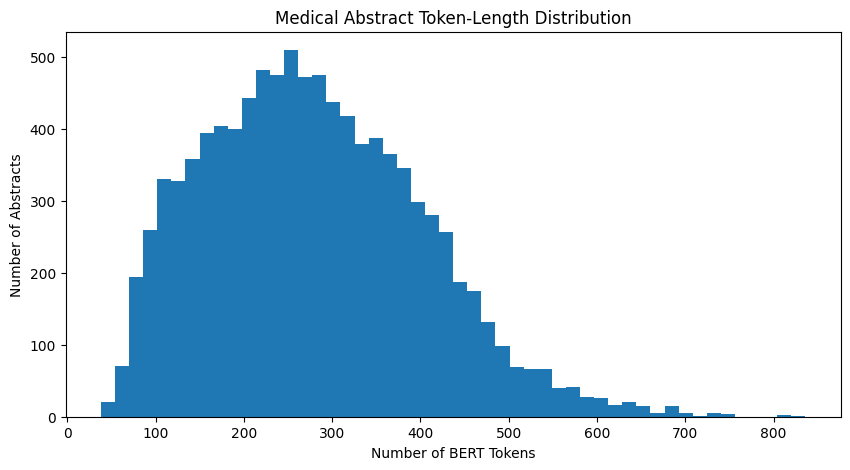

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    train_token_lengths,
    bins=50
)

plt.xlabel("Number of BERT Tokens")
plt.ylabel("Number of Abstracts")
plt.title("Medical Abstract Token-Length Distribution")

plt.show()

In [ ]:
candidate_lengths = [128, 256, 512]

print("Potential truncation rates:")

for max_length in candidate_lengths:
    truncated = np.sum(train_token_lengths > max_length)
    percentage = 100 * truncated / len(train_token_lengths)

    print(
        f"max_length={max_length}: "
        f"{truncated} abstracts "
        f"({percentage:.2f}%) would be truncated"
    )

Potential truncation rates:
max_length=128: 8697 abstracts (88.59%) would be truncated
max_length=256: 5295 abstracts (53.94%) would be truncated
max_length=512: 377 abstracts (3.84%) would be truncated


## 5. BERT Tokenization

The medical abstracts are converted into BERT-compatible numerical
representations using the pretrained BERT tokenizer.

Each abstract is tokenized into subword token IDs and accompanied by an
attention mask. Sequences are truncated to a maximum of 512 tokens and
shorter sequences are padded to the same length.

The maximum length of 512 was selected based on the observed token-length
distribution, where approximately 96% of training abstracts fit within
the limit.

In [ ]:
MAX_LENGTH = 512

print("Model:", MODEL_NAME)
print("Maximum sequence length:", MAX_LENGTH)

Model: bert-base-uncased
Maximum sequence length: 512


In [ ]:
sample_text = train_df.loc[0, "medical_abstract"]

encoded = tokenizer(
    sample_text,
    max_length=MAX_LENGTH,
    padding="max_length",
    truncation=True,
    return_tensors="pt"
)

print("Original text:")
print(sample_text)

print("\nInput IDs shape:")
print(encoded["input_ids"].shape)

print("\nAttention mask shape:")
print(encoded["attention_mask"].shape)

Original text:
Orbital intramuscular schwannoma. In an 8-year-old girl with asymptomatic proptosis, computed tomographic scans showed a large medial orbital mass that contoured the globe anteriorly, bowed the optic nerve laterally, and extended posteriorly to the orbital apex. T1-weighted coronal magnetic resonance images showed the mass to be a diffusely enlarged medial rectus muscle. Histopathologic examination of a medial rectus muscle biopsy specimen disclosed a multinodular, intramuscular schwannoma, separating and infiltrating normal skeletal muscle fibers. The intramuscular location and multinodular configuration of this tumor, together with its occurrence in a child, distinguish it from previous orbital schwannomas. 

Input IDs shape:
torch.Size([1, 512])

Attention mask shape:
torch.Size([1, 512])


## 6. BERT Dataset and DataLoaders

The medical abstracts are converted into fixed-length BERT inputs containing
input IDs and attention masks.

The original dataset labels range from 1 to 5. Since PyTorch classification
loss expects zero-based class indices, the labels are converted to the range
0 to 4.

The tokenized data is wrapped in a custom PyTorch Dataset and supplied to
the model through DataLoaders.

In [ ]:
from torch.utils.data import Dataset, DataLoader


class MedicalAbstractDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_length=512):

        self.texts = dataframe["medical_abstract"].tolist()

        # Convert labels from 1-5 to 0-4
        self.labels = (
            dataframe["condition_label"].values - 1
        ).astype(np.int64)

        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):

        text = self.texts[index]
        label = self.labels[index]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [ ]:
#Creating Datset
BATCH_SIZE = 8
train_dataset = MedicalAbstractDataset(
    train_df,
    tokenizer,
    max_length=MAX_LENGTH
)

val_dataset = MedicalAbstractDataset(
    val_df,
    tokenizer,
    max_length=MAX_LENGTH
)

test_dataset = MedicalAbstractDataset(
    test_df,
    tokenizer,
    max_length=MAX_LENGTH
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 9817
Validation dataset: 1733
Test dataset: 2888


In [ ]:
#Inspect one dataset item
sample = train_dataset[0]

print("Keys:")
print(sample.keys())

print("\nInput IDs shape:")
print(sample["input_ids"].shape)

print("\nAttention mask shape:")
print(sample["attention_mask"].shape)

print("\nLabel:")
print(sample["labels"])

print("\nInput IDs dtype:")
print(sample["input_ids"].dtype)

print("\nAttention mask dtype:")
print(sample["attention_mask"].dtype)

print("\nLabel dtype:")
print(sample["labels"].dtype)

Keys:
dict_keys(['input_ids', 'attention_mask', 'labels'])

Input IDs shape:
torch.Size([512])

Attention mask shape:
torch.Size([512])

Label:
tensor(2)

Input IDs dtype:
torch.int64

Attention mask dtype:
torch.int64

Label dtype:
torch.int64


In [ ]:
#Create DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
#Inspect One complete batch
batch = next(iter(train_loader))

print("Input IDs shape:")
print(batch["input_ids"].shape)

print("\nAttention mask shape:")
print(batch["attention_mask"].shape)

print("\nLabels shape:")
print(batch["labels"].shape)

print("\nLabels:")
print(batch["labels"])

NameError: name 'train_loader' is not defined

## 7. BERT Classification Model

A pretrained BERT-base encoder is used as the feature extractor and is
fine-tuned for medical abstract classification.

The final hidden representation of the `[CLS]` token is extracted from
BERT's last encoder layer. This 768-dimensional representation is passed
through a classification head that produces five class logits.

The BERT parameters remain trainable so that the pretrained language
representations can adapt to the medical abstract classification task.

In [ ]:
from transformers import AutoModel
import torch.nn as nn


class MedicalBERTClassifier(nn.Module):

    def __init__(self, model_name="bert-base-uncased", num_classes=5):
        super().__init__()

        # Pretrained BERT encoder
        self.bert = AutoModel.from_pretrained(model_name)

        # BERT-base hidden dimension = 768
        self.classifier = nn.Linear(
            self.bert.config.hidden_size,
            num_classes
        )

    def forward(self, input_ids, attention_mask):

        # Pass inputs through BERT
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Extract final-layer [CLS] representation
        cls_embedding = outputs.last_hidden_state[:, 0, :]

        # Classification head
        logits = self.classifier(cls_embedding)

        return logits

In [ ]:
#Instantiate the model
model = MedicalBERTClassifier(
    model_name=MODEL_NAME,
    num_classes=5
)

model = model.to(device)

print(model)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MedicalBERTClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [ ]:
# Checking total number of parameters
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 109,486,085
Trainable parameters: 109,486,085


In [ ]:
#Test one batch BEFORE training
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["labels"].to(device)

outputs = model(
    input_ids=input_ids,
    attention_mask=attention_mask
)

print("Input IDs:", input_ids.shape)
print("Attention mask:", attention_mask.shape)
print("Labels:", labels.shape)
print("Model output:", outputs.shape)

Input IDs: torch.Size([8, 512])
Attention mask: torch.Size([8, 512])
Labels: torch.Size([8])
Model output: torch.Size([8, 5])


## 8. Loss Function and Optimizer

The model produces five logits for each medical abstract, corresponding
to the five medical condition categories.

Because the training data is moderately imbalanced, class-weighted
CrossEntropyLoss is used. The class weights are calculated only from the
training subset so that validation and test data do not influence training.

AdamW is used to optimize the BERT parameters and classification head.
A small learning rate is used because the BERT encoder is already
pretrained and is being fine-tuned rather than trained from scratch.

In [ ]:
class_weights_tensor = class_weights_tensor.to(device)

print("Device:", device)
print("Class weights:", class_weights_tensor)

Device: cuda
Class weights: tensor([0.9132, 1.9325, 1.4999, 0.9462, 0.6010], device='cuda:0')


In [ ]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

print(criterion)

CrossEntropyLoss()


In [ ]:
from torch.optim import AdamW
LEARNING_RATE = 2e-5

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Learning rate:", LEARNING_RATE)
print("Optimizer:", optimizer.__class__.__name__)

Learning rate: 2e-05
Optimizer: AdamW


In [ ]:
#One training step
model.train()

batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(
    device,
    non_blocking=True
)

attention_mask = batch["attention_mask"].to(
    device,
    non_blocking=True
)

labels = batch["labels"].to(
    device,
    non_blocking=True
)

# Clear previous gradients
optimizer.zero_grad()

# Forward pass
logits = model(
    input_ids=input_ids,
    attention_mask=attention_mask
)

# Calculate weighted loss
loss = criterion(
    logits,
    labels
)

# Backward pass
loss.backward()

# Update model parameters
optimizer.step()

print("Logits shape:", logits.shape)
print("Loss:", loss.item())

NameError: name 'model' is not defined

In [ ]:
# ============================================================
# Step 9: One-Batch Training Sanity Check
# ============================================================

model.train()

# Get one batch
batch = next(iter(train_loader))

# Move batch to GPU
input_ids = batch["input_ids"].to(device, non_blocking=True)
attention_mask = batch["attention_mask"].to(device, non_blocking=True)
labels = batch["labels"].to(device, non_blocking=True)

# Clear previous gradients
optimizer.zero_grad()

# Forward pass
logits = model(
    input_ids=input_ids,
    attention_mask=attention_mask
)

# Calculate weighted cross-entropy loss
loss = criterion(logits, labels)

# Backward pass
loss.backward()

# Update model parameters
optimizer.step()

# Display results
print("Input IDs shape :", input_ids.shape)
print("Attention mask shape :", attention_mask.shape)
print("Labels shape :", labels.shape)
print("Logits shape :", logits.shape)
print("Loss :", loss.item())

Input IDs shape : torch.Size([8, 512])
Attention mask shape : torch.Size([8, 512])
Labels shape : torch.Size([8])
Logits shape : torch.Size([8, 5])
Loss : 1.7967928647994995


In [ ]:
# ============================================================
# Optimizer Hyperparameters
# ============================================================

LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

print("Learning rate :", LEARNING_RATE)
print("Weight decay  :", WEIGHT_DECAY)

Learning rate : 2e-05
Weight decay  : 0.01


In [ ]:
# ============================================================
# Step 10.1: Reinitialize Model and Optimizer
# ============================================================

model = MedicalBERTClassifier(
    model_name=MODEL_NAME,
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Model and optimizer reinitialized.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model and optimizer reinitialized.


In [ ]:
#Training Function
# ============================================================
# Step 10.1: Training Function
# ============================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in dataloader:

        input_ids = batch["input_ids"].to(
            device, non_blocking=True
        )

        attention_mask = batch["attention_mask"].to(
            device, non_blocking=True
        )

        labels = batch["labels"].to(
            device, non_blocking=True
        )

        # Clear gradients from previous batch
        optimizer.zero_grad()

        # Forward pass
        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Calculate loss
        loss = criterion(logits, labels)

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item() * labels.size(0)

        # Calculate predictions
        predictions = torch.argmax(logits, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
# ============================================================
# Step 10.2: Validation Function
# ============================================================

from sklearn.metrics import accuracy_score, f1_score


def evaluate_model(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for batch in dataloader:

            input_ids = batch["input_ids"].to(
                device, non_blocking=True
            )

            attention_mask = batch["attention_mask"].to(
                device, non_blocking=True
            )

            labels = batch["labels"].to(
                device, non_blocking=True
            )

            # Forward pass
            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            # Calculate loss
            loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)

            # Convert logits into predicted classes
            predictions = torch.argmax(logits, dim=1)

            # Move predictions and labels back to CPU
            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    total = len(all_labels)

    epoch_loss = running_loss / total

    epoch_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    epoch_macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return epoch_loss, epoch_accuracy, epoch_macro_f1

In [ ]:
# ============================================================
# Step 11: Training Loop
# ============================================================

NUM_EPOCHS = 5

best_val_f1 = 0.0

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []
val_f1_scores = []


for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")
    print("-" * 60)

    # -------------------------
    # Training
    # -------------------------
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    # -------------------------
    # Validation
    # -------------------------
    val_loss, val_accuracy, val_f1 = evaluate_model(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    val_f1_scores.append(val_f1)

    # Print results
    print(f"Train Loss     : {train_loss:.4f}")
    print(f"Train Accuracy : {train_accuracy * 100:.2f}%")
    print(f"Val Loss       : {val_loss:.4f}")
    print(f"Val Accuracy   : {val_accuracy * 100:.2f}%")
    print(f"Val Macro-F1   : {val_f1:.4f}")

    # -------------------------
    # Save best model
    # -------------------------
    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_f1": val_f1,
                "val_loss": val_loss
            },
            "best_medical_bert.pt"
        )

        print("✓ Best model saved.")


Epoch [1/5]
------------------------------------------------------------
Train Loss     : 0.9794
Train Accuracy : 56.93%
Val Loss       : 0.8423
Val Accuracy   : 60.47%
Val Macro-F1   : 0.5947
✓ Best model saved.

Epoch [2/5]
------------------------------------------------------------
Train Loss     : 0.7620
Train Accuracy : 64.51%
Val Loss       : 0.8158
Val Accuracy   : 61.74%
Val Macro-F1   : 0.6189
✓ Best model saved.

Epoch [3/5]
------------------------------------------------------------
Train Loss     : 0.6678
Train Accuracy : 67.67%
Val Loss       : 0.8443
Val Accuracy   : 60.42%
Val Macro-F1   : 0.6026

Epoch [4/5]
------------------------------------------------------------
Train Loss     : 0.5888
Train Accuracy : 70.38%
Val Loss       : 0.9134
Val Accuracy   : 59.95%
Val Macro-F1   : 0.5949

Epoch [5/5]
------------------------------------------------------------
Train Loss     : 0.5264
Train Accuracy : 73.07%
Val Loss       : 0.9961
Val Accuracy   : 60.99%
Val Macro-F1  

In [ ]:
# ============================================================
# Step 13.1: Load Best Baseline Model
# ============================================================

checkpoint = torch.load(
    "best_medical_bert.pt",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)
model.eval()

print("Best baseline checkpoint loaded.")
print("Best epoch :", checkpoint["epoch"])
print("Best Val F1:", checkpoint["val_f1"])
print("Best Val Loss:", checkpoint["val_loss"])

Best baseline checkpoint loaded.
Best epoch : 2
Best Val F1: 0.6189356872796363
Best Val Loss: 0.8158274547460791


In [ ]:
# ============================================================
# Step 13.2: Generate Validation Predictions
# ============================================================

all_predictions = []
all_labels = []

with torch.no_grad():

    for batch in val_loader:

        input_ids = batch["input_ids"].to(
            device,
            non_blocking=True
        )

        attention_mask = batch["attention_mask"].to(
            device,
            non_blocking=True
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("Number of validation samples:", len(all_labels))
print("Number of predictions:", len(all_predictions))

Number of validation samples: 1733
Number of predictions: 1733


In [ ]:
# ============================================================
# Step 13.3: Classification Report
# ============================================================

from sklearn.metrics import classification_report

ID_TO_LABEL = {
    0: "Neoplasms",
    1: "Digestive system diseases",
    2: "Nervous system diseases",
    3: "Cardiovascular diseases",
    4: "General pathological conditions"
}

target_names = [
    ID_TO_LABEL[i]
    for i in range(num_classes)
]

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=target_names,
        digits=4
    )
)

                                 precision    recall  f1-score   support

                      Neoplasms     0.7406    0.7737    0.7568       380
      Digestive system diseases     0.4917    0.8268    0.6167       179
        Nervous system diseases     0.4848    0.7619    0.5926       231
        Cardiovascular diseases     0.6826    0.7814    0.7287       366
General pathological conditions     0.6561    0.2877    0.4000       577

                       accuracy                         0.6174      1733
                      macro avg     0.6112    0.6863    0.6189      1733
                   weighted avg     0.6404    0.6174    0.5957      1733



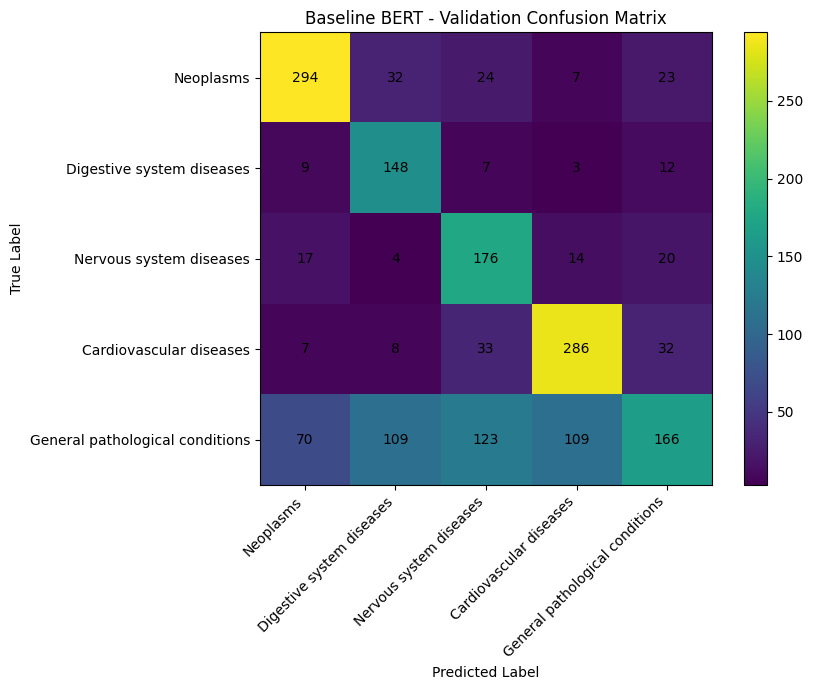

In [ ]:
# ============================================================
# Step 13.4: Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.title("Baseline BERT - Validation Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(num_classes),
    target_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(num_classes),
    target_names
)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

**Unweighted CrossEntropy**

In [ ]:
# ============================================================
# Step 14.1: Unweighted CrossEntropyLoss
# ============================================================

criterion_unweighted = nn.CrossEntropyLoss()

print("Using unweighted CrossEntropyLoss.")

Using unweighted CrossEntropyLoss.


In [ ]:
# ============================================================
# Step 14.2: Fresh Model for Unweighted-Loss Experiment
# ============================================================

model_unweighted = MedicalBERTClassifier(
    model_name=MODEL_NAME,
    num_classes=num_classes
).to(device)

optimizer_unweighted = AdamW(
    model_unweighted.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Fresh unweighted-loss model initialized.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fresh unweighted-loss model initialized.


In [ ]:
# ============================================================
# Step 14.3: Train Unweighted-Loss Baseline
# ============================================================

NUM_EPOCHS_UNWEIGHTED = 5

best_unweighted_f1 = 0.0
best_unweighted_epoch = 0

unweighted_train_losses = []
unweighted_train_accuracies = []

unweighted_val_losses = []
unweighted_val_accuracies = []
unweighted_val_f1_scores = []


for epoch in range(NUM_EPOCHS_UNWEIGHTED):

    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS_UNWEIGHTED}]")
    print("-" * 60)

    # -------------------------
    # Training
    # -------------------------

    train_loss, train_accuracy = train_one_epoch(
        model=model_unweighted,
        dataloader=train_loader,
        criterion=criterion_unweighted,
        optimizer=optimizer_unweighted,
        device=device
    )

    # -------------------------
    # Validation
    # -------------------------

    val_loss, val_accuracy, val_f1 = evaluate_model(
        model=model_unweighted,
        dataloader=val_loader,
        criterion=criterion_unweighted,
        device=device
    )

    # Store metrics

    unweighted_train_losses.append(train_loss)
    unweighted_train_accuracies.append(train_accuracy)

    unweighted_val_losses.append(val_loss)
    unweighted_val_accuracies.append(val_accuracy)
    unweighted_val_f1_scores.append(val_f1)

    print(f"Train Loss     : {train_loss:.4f}")
    print(f"Train Accuracy : {train_accuracy * 100:.2f}%")
    print(f"Val Loss       : {val_loss:.4f}")
    print(f"Val Accuracy   : {val_accuracy * 100:.2f}%")
    print(f"Val Macro-F1   : {val_f1:.4f}")

    # Save best epoch information

    if val_f1 > best_unweighted_f1:

        best_unweighted_f1 = val_f1
        best_unweighted_epoch = epoch + 1

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model_unweighted.state_dict(),
                "optimizer_state_dict": optimizer_unweighted.state_dict(),
                "val_f1": val_f1,
                "val_loss": val_loss
            },
            "best_medical_bert_unweighted.pt"
        )

        print("✓ Best unweighted model saved.")


Epoch [1/5]
------------------------------------------------------------
Train Loss     : 0.9779
Train Accuracy : 59.11%
Val Loss       : 0.8529
Val Accuracy   : 62.67%
Val Macro-F1   : 0.6217
✓ Best unweighted model saved.

Epoch [2/5]
------------------------------------------------------------
Train Loss     : 0.7873
Train Accuracy : 66.19%
Val Loss       : 0.8510
Val Accuracy   : 63.19%
Val Macro-F1   : 0.6268
✓ Best unweighted model saved.

Epoch [3/5]
------------------------------------------------------------
Train Loss     : 0.6991
Train Accuracy : 69.37%
Val Loss       : 0.9087
Val Accuracy   : 61.68%
Val Macro-F1   : 0.6091

Epoch [4/5]
------------------------------------------------------------


KeyboardInterrupt: 

Deleting  the old models and their optimizers for GPU Memory

In [ ]:
del model
del optimizer

del model_unweighted
del optimizer_unweighted

torch.cuda.empty_cache()

In [ ]:
print(torch.cuda.memory_allocated() / 1024**3, "GB allocated")
print(torch.cuda.memory_reserved() / 1024**3, "GB reserved")

4.472507476806641 GB allocated
4.716796875 GB reserved


**Scheduler, Warm-up & Early Stopping**

To further improve the BERT classification baseline, a fresh BERT-base model will be initialized and trained using unweighted Cross-Entropy Loss. This experiment focuses on improving the optimization process rather than changing the model architecture.

The training strategy will incorporate:

AdamW optimizer with a learning rate of 2e-5 and weight decay of 0.01
Linear learning-rate scheduler with 10% warm-up
Gradient clipping with max_norm=1.0 to improve training stability
Early stopping based on validation Macro-F1 to reduce overfitting
A maximum of 8 training epochs

In [ ]:
# ============================================================
# Step 15.1: Fresh BERT Model
# ============================================================

model_scheduler = MedicalBERTClassifier(
    model_name=MODEL_NAME,
    num_classes=num_classes
).to(device)

criterion_scheduler = nn.CrossEntropyLoss()

LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

optimizer_scheduler = AdamW(
    model_scheduler.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Fresh model initialized.")
print("Loss: Unweighted CrossEntropy")
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fresh model initialized.
Loss: Unweighted CrossEntropy
Learning rate: 2e-05
Weight decay: 0.01


In [ ]:
# ============================================================
# Step 15.2: Training Steps
# ============================================================

NUM_EPOCHS = 8

steps_per_epoch = len(train_loader)

total_training_steps = (
    steps_per_epoch * NUM_EPOCHS
)

warmup_steps = int(
    0.10 * total_training_steps
)

print("Steps per epoch      :", steps_per_epoch)
print("Total training steps :", total_training_steps)
print("Warm-up steps        :", warmup_steps)

Steps per epoch      : 1228
Total training steps : 9824
Warm-up steps        : 982


In [ ]:
# ============================================================
# Step 15.3: Linear Warm-up + Decay
# ============================================================

from transformers import get_linear_schedule_with_warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer_scheduler,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

print("Scheduler created successfully.")

Scheduler created successfully.


In [ ]:
# ============================================================
# Step 15.4: Training Function
# ============================================================

def train_one_epoch_scheduler(
    model,
    dataloader,
    criterion,
    optimizer,
    scheduler,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in dataloader:

        input_ids = batch["input_ids"].to(
            device,
            non_blocking=True
        )

        attention_mask = batch["attention_mask"].to(
            device,
            non_blocking=True
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Loss
        loss = criterion(logits, labels)

        # Backpropagation
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        # Update model parameters
        optimizer.step()

        # Update learning rate
        scheduler.step()

        # Track loss
        running_loss += (
            loss.item() * labels.size(0)
        )

        # Predictions
        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
# ============================================================
# Step 15.5: Scheduler Training Loop + Early Stopping
# ============================================================

PATIENCE = 2

best_val_f1 = 0.0
epochs_without_improvement = 0

train_losses_scheduler = []
train_accuracies_scheduler = []

val_losses_scheduler = []
val_accuracies_scheduler = []
val_f1_scores_scheduler = []

learning_rates_scheduler = []


for epoch in range(NUM_EPOCHS):

    print(
        f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]"
    )

    print("-" * 60)

    # -------------------------
    # Training
    # -------------------------

    train_loss, train_accuracy = (
        train_one_epoch_scheduler(
            model=model_scheduler,
            dataloader=train_loader,
            criterion=criterion_scheduler,
            optimizer=optimizer_scheduler,
            scheduler=scheduler,
            device=device
        )
    )

    # -------------------------
    # Validation
    # -------------------------

    val_loss, val_accuracy, val_f1 = (
        evaluate_model(
            model=model_scheduler,
            dataloader=val_loader,
            criterion=criterion_scheduler,
            device=device
        )
    )

    # Current learning rate
    current_lr = (
        optimizer_scheduler
        .param_groups[0]["lr"]
    )

    # Store metrics

    train_losses_scheduler.append(
        train_loss
    )

    train_accuracies_scheduler.append(
        train_accuracy
    )

    val_losses_scheduler.append(
        val_loss
    )

    val_accuracies_scheduler.append(
        val_accuracy
    )

    val_f1_scores_scheduler.append(
        val_f1
    )

    learning_rates_scheduler.append(
        current_lr
    )

    # -------------------------
    # Print
    # -------------------------

    print(
        f"Train Loss     : {train_loss:.4f}"
    )

    print(
        f"Train Accuracy : "
        f"{train_accuracy * 100:.2f}%"
    )

    print(
        f"Val Loss       : {val_loss:.4f}"
    )

    print(
        f"Val Accuracy   : "
        f"{val_accuracy * 100:.2f}%"
    )

    print(
        f"Val Macro-F1   : {val_f1:.4f}"
    )

    print(
        f"Learning Rate  : {current_lr:.8f}"
    )

    # -------------------------
    # Best model
    # -------------------------

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict":
                    model_scheduler.state_dict(),
                "optimizer_state_dict":
                    optimizer_scheduler.state_dict(),
                "scheduler_state_dict":
                    scheduler.state_dict(),
                "val_f1": val_f1,
                "val_loss": val_loss
            },
            "best_medical_bert_scheduler.pt"
        )

        print("✓ Best scheduler model saved.")

    else:

        epochs_without_improvement += 1

        print(
            f"No improvement for "
            f"{epochs_without_improvement} epoch(s)."
        )

    # -------------------------
    # Early stopping
    # -------------------------

    if epochs_without_improvement >= PATIENCE:

        print(
            "\nEarly stopping triggered."
        )

        break


Epoch [1/8]
------------------------------------------------------------
Train Loss     : 1.1161
Train Accuracy : 52.68%
Val Loss       : 0.9117
Val Accuracy   : 61.40%
Val Macro-F1   : 0.5529
Learning Rate  : 0.00001944
✓ Best scheduler model saved.

Epoch [2/8]
------------------------------------------------------------
Train Loss     : 0.8417
Train Accuracy : 64.91%
Val Loss       : 0.8787
Val Accuracy   : 63.30%
Val Macro-F1   : 0.6230
Learning Rate  : 0.00001667
✓ Best scheduler model saved.

Epoch [3/8]
------------------------------------------------------------
